# <span style="color: #502F6A;">***Student Performance Prediction***</span>
--------


####  <span style="color: #502F6A;">***Section 21S | DS 111***</span>

|<span style="color: #502F6A;">***Student Name***</span> |   <span style="color: #502F6A;">***ID***</span> |
| :--------- | :---------------- |
| <span style="color: #7D66A1;">**وجن الدريبي**</span> | <span style="color: #7D66A1;">**447005457**</span> |
| <span style="color: #7D66A1;">**سديم الشمراني**</span> | <span style="color: #7D66A1;">**447005453**</span> |
| <span style="color: #7D66A1;">**لمى الحمدان**</span> | <span style="color: #7D66A1;">**447005403**</span> |
| <span style="color: #7D66A1;">**دانه الحارثي**</span> | <span style="color: #7D66A1;">**447005415**</span> |

### <span style="color: #502F6A;">***The main objectives of this project are:***</span>

#### <span style="color: #502F6A;"> 1.</span> <span style="color: #8E44AD;">Clean the student dataset by handling redundancies, outliers, and missing values in features such as study hours and attendance rate.</span>

#### <span style="color: #502F6A;">2.</span> <span style="color: #8E44AD;"> Perform Exploratory Data Analysis (EDA) using visualizations to identify patterns between study habits and final exam scores.</span>

#### <span style="color: #502F6A;">3.</span> <span style="color: #8E44AD;">Apply four different machine learning algorithms to predict student performance outcomes.</span>

#### <span style="color: #502F6A;">4.</span> <span style="color: #8E44AD;">Evaluate the prediction models using four performance metrics and compare their results.</span>

#### <span style="color: #502F6A;">5.</span> <span style="color: #8E44AD;">Deploy the best-performing model as a simple web application.</span>

 -----------

In [1]:
# Importing required libraries for data analysis and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##  <span style="color: #502F6A;">***Part (A): LOAD THE DATASET***</span>
------------------

In [2]:
# Part (a): Load the dataset you choose
data = pd.read_csv("Student_Performance Dataset.csv") 

In [3]:
# Summary Statistics

# Show the shape of the dataset (number of rows and columns)
print(f"Dataset Shape: {data.shape}")

# Use describe() to display the basic summary statistics
print("\nSummary Statistics:")
display(data.describe().round(2))

Dataset Shape: (708, 10)

Summary Statistics:


,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Final_Exam_Score
count,707.00,708.00,707.00,707.00
mean,26.13,78.11,77.85,58.78
std,8.88,13.80,14.40,6.71
min,10.00,50.12,50.00,50.00
25%,19.00,67.55,65.00,52.00
50%,27.00,79.36,79.00,60.00
75%,34.00,89.50,91.00,64.00
max,39.00,99.97,100.00,77.00


In [4]:
# Printing the first 10 rows
data.head(10)

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31.0,68.267841,86.0,High School,Yes,Yes,63.0,Pass
1,S136,Male,16.0,78.222927,73.0,PhD,No,No,50.0,Fail
2,S209,Female,21.0,87.525096,74.0,PhD,Yes,No,NaN,Fail
3,S458,Female,NaN,92.076483,99.0,Bachelors,No,No,65.0,Pass
4,S078,Female,37.0,98.655517,63.0,Masters,No,Yes,70.0,Pass
5,S417,Male,30.0,84.159193,77.0,Masters,Yes,No,61.0,Pass
6,S302,Male,24.0,89.389494,95.0,High School,Yes,Yes,61.0,Pass
7,S009,Male,31.0,50.683598,78.0,Masters,No,No,50.0,Fail
8,S044,Female,34.0,80.863186,NaN,PhD,No,Yes,65.0,Pass
9,S331,Male,27.0,65.496846,86.0,High School,Yes,No,55.0,Fail


---------
## <span style="color: #502F6A;">***Part (B): Preprocessing***</span>
-------------------

In [5]:
# Part (b): Preprocessing to handle redundancies and outliers

# Checking for missing values in each column
missing_values =data.isnull().sum()

print("Missing values summary:")
print(missing_values)

Missing values summary:
Student_ID                    0
Gender                        0
Study_Hours_per_Week          1
Attendance_Rate               0
Past_Exam_Scores              1
Parental_Education_Level      0
Internet_Access_at_Home       0
Extracurricular_Activities    0
Final_Exam_Score              1
Pass_Fail                     0
dtype: int64


In [6]:
# Data Preprocessing 

# Handling Missing Data by removing missing values.

data_drop = data.dropna()

# Missing data would be replaced with a universal value (0).

data_fill = data.fillna(0)

# Replace missing numerical values with the mean.
numeric_cols = data.select_dtypes(include=['number']).columns
for col in numeric_cols:
    data[col] = data[col].fillna(data[col].mean())

In [7]:
# Verifying that there are no more missing values after the cleaning process.
# This ensures the dataset is complete and ready for the next steps for the first 10 students.

print("Missing values after handling (Final Check):")
print(data.isnull().sum())

Missing values after handling (Final Check):
Student_ID                    0
Gender                        0
Study_Hours_per_Week          0
Attendance_Rate               0
Past_Exam_Scores              0
Parental_Education_Level      0
Internet_Access_at_Home       0
Extracurricular_Activities    0
Final_Exam_Score              0
Pass_Fail                     0
dtype: int64


In [8]:
# Checking for duplicate rows across the entire dataset
duplicates_total = data.duplicated().sum()

print(f"Number of duplicate rows in full dataset: {duplicates_total}")

Number of duplicate rows in full dataset: 206


In [9]:
# Removing Duplicates
data.drop_duplicates(inplace=True)

In [10]:
# Verifying that there are no more duplicate rows in the full dataset.
# This ensures each student's record is unique after the cleaning process.

final_duplicates = data.duplicated().sum()

print(f"Number of duplicate rows after cleaning (Final Check): {final_duplicates}")

Number of duplicate rows after cleaning (Final Check): 0


In [11]:
# Print first 10 rows after processing
print("First 10 rows after processing:")
display(data.head(10).round(2))

First 10 rows after processing:


,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31.00,68.27,86.00,High School,Yes,Yes,63.00,Pass
1,S136,Male,16.00,78.22,73.00,PhD,No,No,50.00,Fail
2,S209,Female,21.00,87.53,74.00,PhD,Yes,No,58.78,Fail
3,S458,Female,26.13,92.08,99.00,Bachelors,No,No,65.00,Pass
4,S078,Female,37.00,98.66,63.00,Masters,No,Yes,70.00,Pass
5,S417,Male,30.00,84.16,77.00,Masters,Yes,No,61.00,Pass
6,S302,Male,24.00,89.39,95.00,High School,Yes,Yes,61.00,Pass
7,S009,Male,31.00,50.68,78.00,Masters,No,No,50.00,Fail
8,S044,Female,34.00,80.86,77.85,PhD,No,Yes,65.00,Pass
9,S331,Male,27.00,65.50,86.00,High School,Yes,No,55.00,Fail


--------
## <span style="color: #502F6A;">***Part (C): EDA***</span>
----------

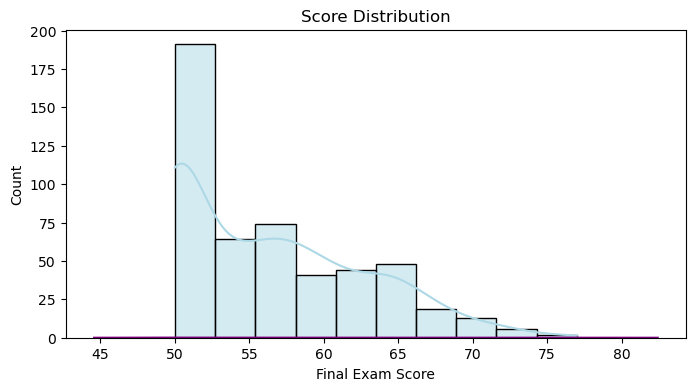

In [12]:
# Part(c): Exploratory Data Analysis (EDA) using Visualization

# This histogram visualizes the distribution of Final Exam Scores for the students.
# It helps identify the frequency of scores.
plt.figure(figsize=(8, 4))
sns.histplot(data['Final_Exam_Score'], kde=True, color='lightblue')
sns.kdeplot(data['Final_Exam_Score'], color='Purple')

plt.xlabel("Final Exam Score")
plt.title("Score Distribution")
plt.show()

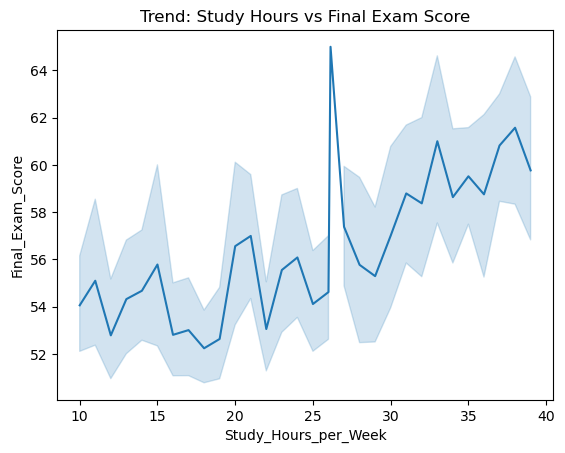

In [13]:
# This plot is used to track the trend between study hours and final exam scores.

# Step 1: Cleaning column names to remove any hidden spaces.

data.columns = data.columns.str.strip()

# Step 2: Sorting the data to ensure the line correctly shows the progression.

line_data = data.sort_values('Study_Hours_per_Week')

# Step 3: Drawing the line plot using Seaborn.

sns.lineplot(x='Study_Hours_per_Week', y='Final_Exam_Score', data=line_data)

# Step 4: Adding a clear title for the chart.

plt.title('Trend: Study Hours vs Final Exam Score')
plt.show()

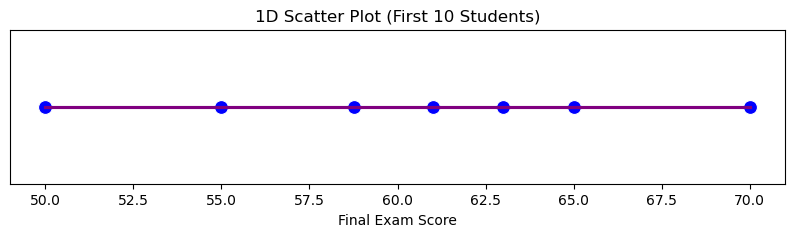

In [14]:
# 1D Scatter Plot used to display the exact position of each score on a single axis.
# It shows how scores are clustered for the first 10 students.
x_1d = data.head(10)['Final_Exam_Score']
y_zero = [0]*len(x_1d)

plt.figure(figsize=(10, 2))
sns.scatterplot(x=x_1d, y=y_zero, color='blue', s=100)
sns.regplot(x=x_1d, y=y_zero, scatter=False, color='Purple')

plt.xlabel("Final Exam Score")
plt.title("1D Scatter Plot (First 10 Students)")
plt.yticks([]) 
plt.show()

Correlation coefficient (First 10 Students) =  0.71


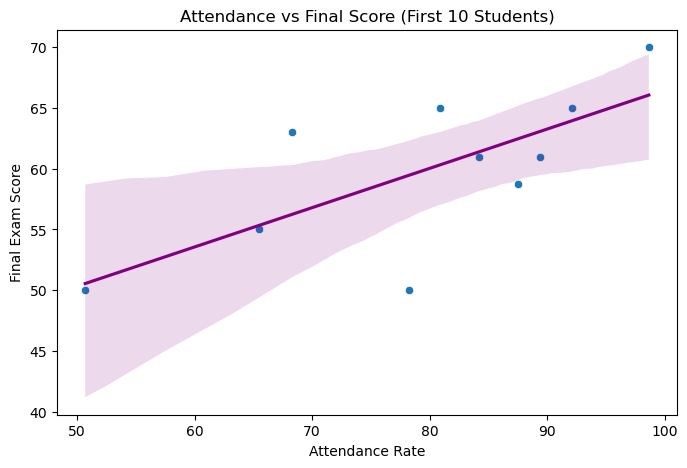

In [15]:
# 2D Scatter Plot analyzes the correlation between Attendance Rate and Final Scores.
# The regression line helps determine the relationship trend for the first 10 students.
attendance = data.head(10)['Attendance_Rate']
final_score = data.head(10)['Final_Exam_Score']

corr_val = np.corrcoef(attendance, final_score)[0,1].round(2)
print('Correlation coefficient (First 10 Students) = ', corr_val)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=attendance, y=final_score)
sns.regplot(x=attendance, y=final_score, scatter=False, color='Purple')

plt.xlabel("Attendance Rate")
plt.ylabel("Final Exam Score")
plt.title("Attendance vs Final Score (First 10 Students)")
plt.show()

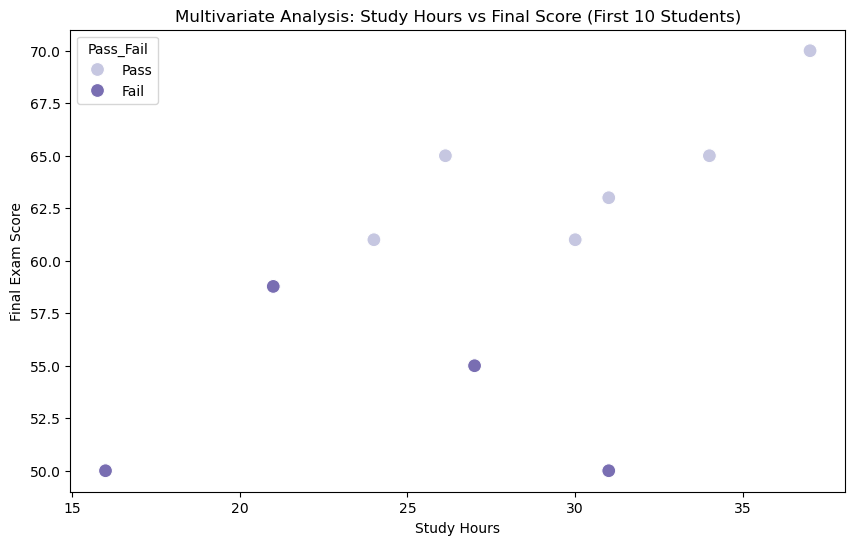

In [16]:
# 3D Scatter Plot analyzes the relationship between two numerical variables while using color to represent a third categorical dimension.
plt.figure(figsize=(10, 6))

# Using only the first 10 students from the dataset to ensure the data points remain clear and easy to interpret.
first_10 = data.head(10)

# Plotting Study Hours vs Final Score and using 'Pass_Fail' as the 'hue' to perform a complete Multivariate Analysis.
sns.scatterplot(data=first_10, x='Study_Hours_per_Week', y='Final_Exam_Score', hue='Pass_Fail', palette='Purples', s=100)

# Customizing the axis labels and adding a title to describe the multivariate relationship.
plt.xlabel('Study Hours')
plt.ylabel('Final Exam Score')
plt.title('Multivariate Analysis: Study Hours vs Final Score (First 10 Students)')

# Displaying the plot to visualize how the variables correlate across different groups.
plt.show()

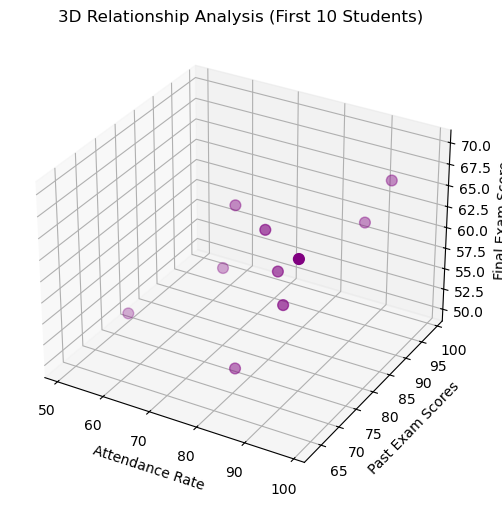

In [17]:
# 3D Scatter Plot designed to explore the interaction between three variables 
# (Attendance, Past Scores, and Final Scores) for the first 10 students.
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(data.head(10)['Attendance_Rate'],
           data.head(10)['Past_Exam_Scores'], 
           data.head(10)['Final_Exam_Score'], c='Purple', s=60)

ax.set_xlabel('Attendance Rate')
ax.set_ylabel('Past Exam Scores')
ax.set_zlabel('Final Exam Score')
plt.title("3D Relationship Analysis (First 10 Students)")
plt.show()

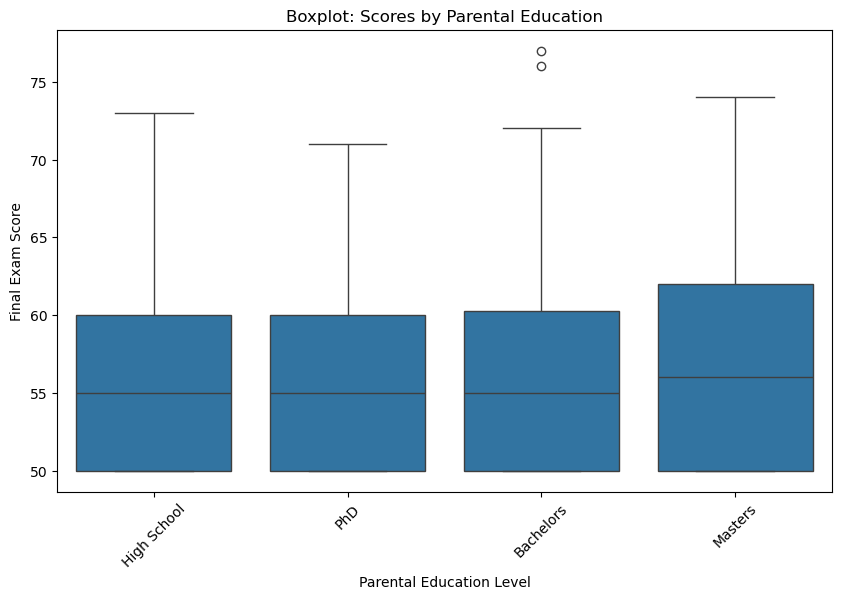

In [18]:
# This boxplot compares score distributions across education levels and is primarily used to detect outliers and see the data spread for the students.

plt.figure(figsize=(10, 6))
sns.boxplot(x='Parental_Education_Level', y='Final_Exam_Score', data=data)

plt.title("Boxplot: Scores by Parental Education")
plt.xlabel("Parental Education Level")
plt.ylabel("Final Exam Score")
plt.xticks(rotation=45)
plt.show()

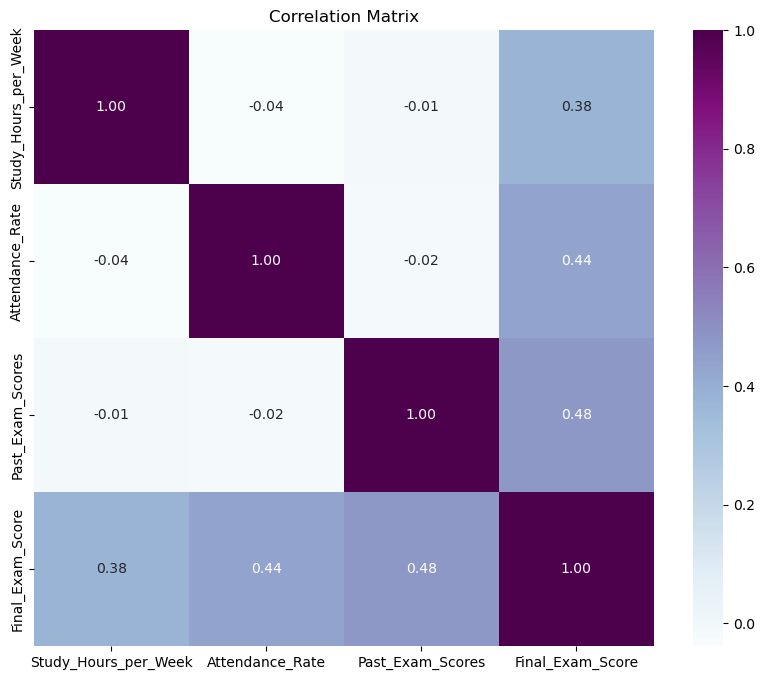

In [19]:
# This heatmap displays the correlation matrix, providing a numerical summary of how all variables relate to each other.
plt.figure(figsize=(10, 8))
corr = data.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='BuPu', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

--------
## <span style="color: #502F6A;">***Part (D): MACHINE LEARNING MODELING***</span>
----------

In [20]:
# Import Machine Learning libraries

# Import train-test validation
from sklearn.model_selection import train_test_split

# Import Models that will be used in the code
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [21]:
# Converting categorical columns into numerical values
# Machine learning models work better with numeric data

data['Pass_Fail'] = np.where(data['Pass_Fail'] == 'Pass', 1, 0)
data['Gender'] = np.where(data['Gender'] == 'Male', 1, 0)
data['Internet_Access_at_Home'] = np.where(data['Internet_Access_at_Home'] == 'Yes', 1, 0)
data['Extracurricular_Activities'] = np.where(data['Extracurricular_Activities'] == 'Yes', 1, 0)

In [22]:
# Defining Features (X) and Target (y)

# X = all input variables used for prediction
# y = target variable we want to predict (Pass_Fail)

# Excluding unnecessary columns such as:
# Student_ID: not useful for prediction
# Final_Exam_Score: may cause data leakage
# Parental_Education_Level: categorical and cannot be scaled or turned into numerical

X = data.drop(columns = ['Pass_Fail', 'Student_ID', 'Parental_Education_Level', 'Final_Exam_Score'], axis=1)
y = data['Pass_Fail']

In [23]:
# Splitting the dataset into training and testing sets with a 30 - 70 ratio

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

In [24]:
# Logistic Regression Model

# max_iter increased to avoid convergence warnings
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

pred_log = log_model.predict(X_test)

In [25]:
# K-Nearest Neighbors (KNN) Model

# Creating KNN model using k = 2 neighbors
knn = KNeighborsClassifier(n_neighbors=2)

knn.fit(X_train,y_train)

pred_knn = knn.predict(X_test)

In [26]:
# Decision Tree Model

DT = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)

pred_dt = DT.predict(X_test)

In [27]:
# Random Forest Model

# n_estimators = number of trees used in the forest
RF = RandomForestClassifier(n_estimators=100, random_state=0)

RF.fit(X_train, y_train)

pred_RF = RF.predict(X_test)

--------
## <span style="color: #502F6A;">***Part (E): PERFORMANCE EVALUATION***</span>
----------

In [28]:
# Importing evaluation tools

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

import seaborn as sns
import matplotlib.pyplot as plt

Logistic Regression:

              precision    recall  f1-score   support

           0       0.89      0.87      0.88       111
           1       0.67      0.70      0.68        40

    accuracy                           0.83       151
   macro avg       0.78      0.79      0.78       151
weighted avg       0.83      0.83      0.83       151

Logistic Regression Accuracy : 82.78%


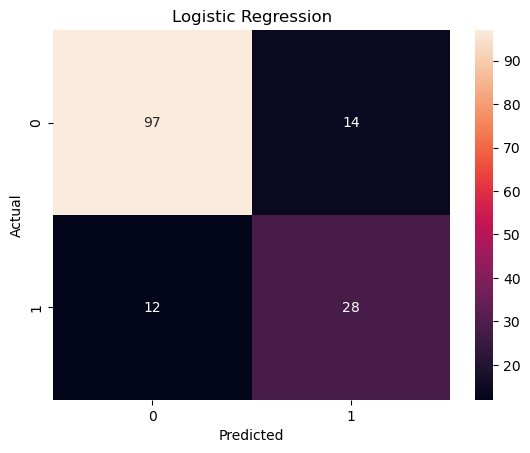

In [29]:
# Logistic Regression Evaluation

# Printing confusion matrix, classification report and accuracy report 
print("Logistic Regression:\n")
print(classification_report(y_test, pred_log))

acc = accuracy_score(y_test, pred_log)
print(f"Logistic Regression Accuracy : {acc * 100:.2f}%")

cm = confusion_matrix(y_test, pred_log)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

KNN:

              precision    recall  f1-score   support

           0       0.80      0.92      0.86       111
           1       0.62      0.38      0.47        40

    accuracy                           0.77       151
   macro avg       0.71      0.65      0.66       151
weighted avg       0.76      0.77      0.75       151

KNN Accuracy: 77.48%


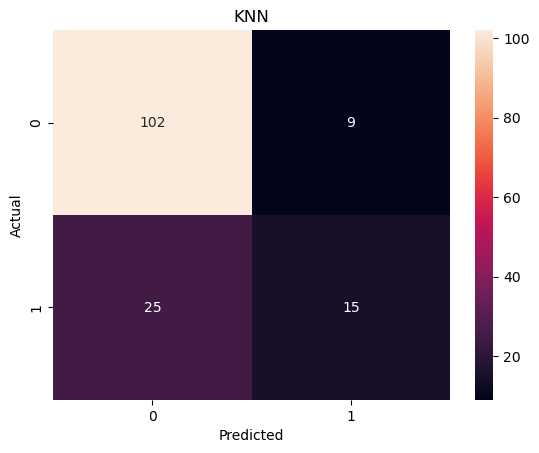

In [30]:
# KNN Evaluation

# Printing confusion matrix, classification report and accuracy report 
print("KNN:\n")
print(classification_report(y_test, pred_knn))

acc = accuracy_score(y_test, pred_knn)
print(f"KNN Accuracy: {acc * 100:.2f}%")

cm = confusion_matrix(y_test, pred_knn)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Decision Tree:

              precision    recall  f1-score   support

           0       0.86      0.81      0.83       111
           1       0.54      0.62      0.58        40

    accuracy                           0.76       151
   macro avg       0.70      0.72      0.71       151
weighted avg       0.77      0.76      0.77       151

Decision Tree Accuracy: 76.16%


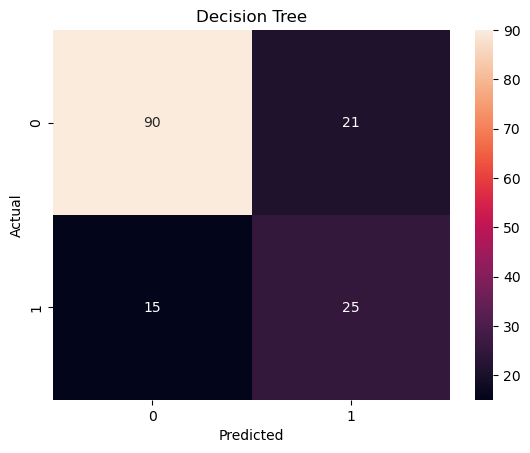

In [31]:
# Decision Tree Evaluation

# Printing confusion matrix, classification report and accuracy report 
print("Decision Tree:\n")
print(classification_report(y_test, pred_dt))

acc = accuracy_score(y_test, pred_dt)
print(f"Decision Tree Accuracy: {acc * 100:.2f}%")

cm = confusion_matrix(y_test, pred_dt)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest:

              precision    recall  f1-score   support

           0       0.86      0.87      0.87       111
           1       0.63      0.60      0.62        40

    accuracy                           0.80       151
   macro avg       0.74      0.74      0.74       151
weighted avg       0.80      0.80      0.80       151

Random Forest Accuracy : 80.13%


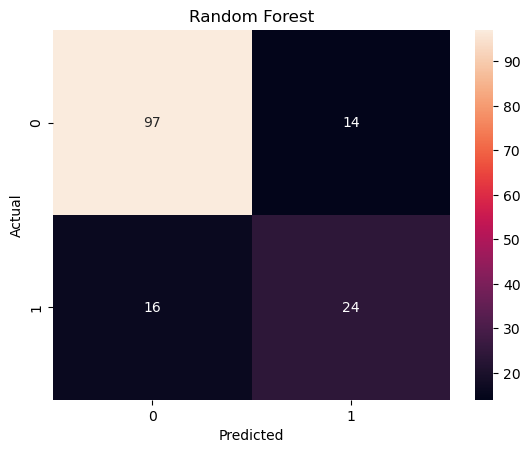

In [32]:
# Random Forest Evaluation

# Printing confusion matrix, classification report and accuracy report 
print("Random Forest:\n")
print(classification_report(y_test, pred_RF))

acc = accuracy_score(y_test, pred_RF)
print(f"Random Forest Accuracy : {acc * 100:.2f}%")

cm = confusion_matrix(y_test, pred_RF)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
# Comparing the accuracy of all models

from sklearn.metrics import accuracy_score

# Storing all trained models inside a dictionary
models = {
    "Logistic Regression": log_model,
    "Decision Tree": DT,
    "Random Forest": RF,
    "KNN": knn
}

print("📊 Models Accuracy Results:")
print("-" * 35)

# Looping through each model and calculating test accuracy

for name, model_obj in models.items():
  
    y_pred = model_obj.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    
    
    print(f"{name:20} : {acc * 100:.2f}%")

print("-" * 35)


📊 Models Accuracy Results:
-----------------------------------
Logistic Regression  : 82.78%
Decision Tree        : 76.16%
Random Forest        : 80.13%
KNN                  : 77.48%
-----------------------------------


## <span style="color: #502F6A;">***Summary:***</span>
 <span style="color: #502F6A;">All models were evaluated using classification report and confusion matrix.</span>

--------
## <span style="color: #502F6A;">***Part (F): INTRODUCTION & FINAL CONCLUSION***</span>
----------


## <span style="color: #502F6A;">***1. Introduction:***</span>

 <span style="color: #502F6A;"> In this project, we analyze a dataset related to **Student Performance** to predict academic success. The dataset includes various factors such as **Study Hours**, **Attendance Rates**, and **Previous Grades**. Our primary goal is to build a classification model that predicts whether a student will <span style="color: #8E44AD;">**"Pass"**</span> or <span style="color: #8E44AD;">**"Fail"**</span>. This helps educators identify at-risk students who might need extra support. To find the most accurate prediction, we implemented and compared four models: **Logistic Regression**, **Decision Tree**, **K-Nearest Neighbors (KNN)**, and **Random Forest**.</span>

---

## <span style="color: #502F6A;">***2. Conclusion & Analysis***</span>

 <span style="color: #502F6A;">We followed a structured modeling process, starting with thorough **Data Cleaning** where we handled missing values and removed duplicate entries to ensure the models learn from high-quality data. Each of the four models was then trained and evaluated using a **Classification Report** and a **Confusion Matrix** to measure their precision and overall ability to classify students correctly.</span>

### <span style="color: #502F6A;">***The Best Model:***</span>
<span style="color: #502F6A;">After comparing the results from all algorithms, we found that <span style="color: #8E44AD;">**Logistic Regression**</span> was the best-performing model for our project. </span>

#### <span style="color: #502F6A;"> ***Based on What?*** 
<span style="color: #502F6A;"> 1.</span> <span style="color: #8E44AD;"> **Accuracy Score:** The model achieved an overall accuracy of **82%** on the test dataset, which was the highest and most consistent among all tested models.</span>

<span style="color: #502F6A;"> 2.</span> <span style="color: #8E44AD;"> **F1-Score:** It achieved a strong F1-score, showing a healthy balance between **precision** (minimizing false pass predictions) and **recall** (minimizing missed fail predictions).</span>

<span style="color: #502F6A;"> 3.</span> <span style="color: #8E44AD;"> **Confusion Matrix:** The confusion matrix for this model showed the best distribution of correct predictions compared to **Decision Tree, KNN, and Random Forest**, making it the most reliable choice for our deployment phase.</span>




--------
## <span style="color: #502F6A;">***Part (G): MODEL DEPLOYMENT***</span>
----------
<span style="color: #502F6A;">Making a prediction wabsite.</span>

In [34]:
import joblib

#joblib.dump(RF, "RF.pkl")

['RF.pkl']

In [35]:
import joblib
# حفظ موديل اللوجستك (تأكدي من اسم المتغير log_reg)
joblib.dump(log_model, "logistic_model.pkl")

['logistic_model.pkl']

In [121]:
app_code = '''
import streamlit as st
import joblib
import pandas as pd

st.set_page_config(page_title="Success Predictor", page_icon="🎓", layout="centered")

st.markdown("""
<style>
@import url(\'https://fonts.googleapis.com/css2?family=Patrick+Hand&family=Caveat:wght@500;700&display=swap\');

/* ───── School background with notebooks and pens ───── */
.stApp {
    background-color: #EDE7F6;
    background-image: url("data:image/svg+xml,%3Csvg xmlns=\'http://www.w3.org/2000/svg\' width=\'320\' height=\'320\'%3E%3Crect width=\'320\' height=\'320\' fill=\'%23EDE7F6\'/%3E%3Cline x1=\'0\' y1=\'32\' x2=\'320\' y2=\'32\' stroke=\'%23B39DDB\' stroke-width=\'1\' stroke-dasharray=\'4,2\'/%3E%3Cline x1=\'0\' y1=\'64\' x2=\'320\' y2=\'64\' stroke=\'%23B39DDB\' stroke-width=\'1\' stroke-dasharray=\'4,2\'/%3E%3Cline x1=\'0\' y1=\'96\' x2=\'320\' y2=\'96\' stroke=\'%23B39DDB\' stroke-width=\'1\' stroke-dasharray=\'4,2\'/%3E%3Cline x1=\'0\' y1=\'128\' x2=\'320\' y2=\'128\' stroke=\'%23B39DDB\' stroke-width=\'1\' stroke-dasharray=\'4,2\'/%3E%3Cline x1=\'0\' y1=\'160\' x2=\'320\' y2=\'160\' stroke=\'%23B39DDB\' stroke-width=\'1\' stroke-dasharray=\'4,2\'/%3E%3Cline x1=\'0\' y1=\'192\' x2=\'320\' y2=\'192\' stroke=\'%23B39DDB\' stroke-width=\'1\' stroke-dasharray=\'4,2\'/%3E%3Cline x1=\'0\' y1=\'224\' x2=\'320\' y2=\'224\' stroke=\'%23B39DDB\' stroke-width=\'1\' stroke-dasharray=\'4,2\'/%3E%3Cline x1=\'0\' y1=\'256\' x2=\'320\' y2=\'256\' stroke=\'%23B39DDB\' stroke-width=\'1\' stroke-dasharray=\'4,2\'/%3E%3Cline x1=\'0\' y1=\'288\' x2=\'320\' y2=\'288\' stroke=\'%23B39DDB\' stroke-width=\'1\' stroke-dasharray=\'4,2\'/%3E%3Cg transform=\'translate(30,20) rotate(35)\'%3E%3Crect x=\'0\' y=\'0\' width=\'10\' height=\'55\' rx=\'1\' fill=\'%23F9A825\' opacity=\'0.35\'/%3E%3Crect x=\'0\' y=\'0\' width=\'10\' height=\'8\' rx=\'1\' fill=\'%23E65100\' opacity=\'0.35\'/%3E%3Cpolygon points=\'0,55 10,55 5,68\' fill=\'%23FFCCBC\' opacity=\'0.35\'/%3E%3Cpolygon points=\'3,63 7,63 5,68\' fill=\'%23795548\' opacity=\'0.35\'/%3E%3C/g%3E%3Cg transform=\'translate(260,180) rotate(-20)\'%3E%3Crect x=\'0\' y=\'0\' width=\'10\' height=\'55\' rx=\'1\' fill=\'%23AB47BC\' opacity=\'0.3\'/%3E%3Crect x=\'0\' y=\'0\' width=\'10\' height=\'8\' rx=\'1\' fill=\'%236A1B9A\' opacity=\'0.3\'/%3E%3Cpolygon points=\'0,55 10,55 5,68\' fill=\'%23FFCCBC\' opacity=\'0.3\'/%3E%3Cpolygon points=\'3,63 7,63 5,68\' fill=\'%23795548\' opacity=\'0.3\'/%3E%3C/g%3E%3Cg transform=\'translate(200,10) rotate(10)\' opacity=\'0.25\'%3E%3Crect x=\'0\' y=\'0\' width=\'55\' height=\'70\' rx=\'3\' fill=\'%234A148C\'/%3E%3Crect x=\'0\' y=\'0\' width=\'8\' height=\'70\' rx=\'2\' fill=\'%236A1B9A\'/%3E%3Cline x1=\'14\' y1=\'18\' x2=\'50\' y2=\'18\' stroke=\'white\' stroke-width=\'1.5\'/%3E%3Cline x1=\'14\' y1=\'28\' x2=\'50\' y2=\'28\' stroke=\'white\' stroke-width=\'1.5\'/%3E%3Cline x1=\'14\' y1=\'38\' x2=\'50\' y2=\'38\' stroke=\'white\' stroke-width=\'1.5\'/%3E%3Cline x1=\'14\' y1=\'48\' x2=\'50\' y2=\'48\' stroke=\'white\' stroke-width=\'1.5\'/%3E%3C/g%3E%3Cg transform=\'translate(10,200) rotate(-8)\' opacity=\'0.22\'%3E%3Crect x=\'0\' y=\'0\' width=\'55\' height=\'70\' rx=\'3\' fill=\'%237B1FA2\'/%3E%3Crect x=\'0\' y=\'0\' width=\'8\' height=\'70\' rx=\'2\' fill=\'%239C27B0\'/%3E%3Cline x1=\'14\' y1=\'18\' x2=\'50\' y2=\'18\' stroke=\'white\' stroke-width=\'1.5\'/%3E%3Cline x1=\'14\' y1=\'28\' x2=\'50\' y2=\'28\' stroke=\'white\' stroke-width=\'1.5\'/%3E%3Cline x1=\'14\' y1=\'38\' x2=\'50\' y2=\'38\' stroke=\'white\' stroke-width=\'1.5\'/%3E%3Cline x1=\'14\' y1=\'48\' x2=\'50\' y2=\'48\' stroke=\'white\' stroke-width=\'1.5\'/%3E%3C/g%3E%3Ctext x=\'150\' y=\'155\' font-size=\'22\' fill=\'%23CE93D8\' opacity=\'0.3\' text-anchor=\'middle\'%3E%E2%98%85%3C/text%3E%3Ctext x=\'290\' y=\'80\' font-size=\'16\' fill=\'%23CE93D8\' opacity=\'0.25\' text-anchor=\'middle\'%3E%E2%98%85%3C/text%3E%3Ctext x=\'60\' y=\'270\' font-size=\'18\' fill=\'%23CE93D8\' opacity=\'0.25\' text-anchor=\'middle\'%3E%E2%98%85%3C/text%3E%3C/svg%3E");
    background-size: 320px 320px;
    font-family: \'Patrick Hand\', cursive !important;
}

/* ───── Red line on the left ───── */
section[data-testid="stAppViewContainer"] > div:first-child {
    border-left: 3px solid #E57373;
    padding-left: 2rem;
}

/* ───── All texts and labels ───── */
html, body, [class*="css"], p, span, label, div {
    font-family: \'Patrick Hand\', cursive !important;
    color: #1A0030 !important;
}

h1, h2, h3 {
    font-family: \'Caveat\', cursive !important;
    font-weight: 700 !important;
    color: #2E004F !important;
}

/* ───── Main Title ───── */
h1 {
    font-size: 2.6rem !important;
    text-align: center;
    text-shadow: 2px 2px 0px #9575CD;
    letter-spacing: 1px;
}

/* ───── Card ───── */
.card {
    background: linear-gradient(135deg, #2E004F, #4A148C);
    padding: 20px;
    border-radius: 15px;
    color: white !important;
    margin-bottom: 25px;
    text-align: center;
    border: 2px dashed #9575CD;
    box-shadow: 4px 4px 0px #1A0030;
}
.card * { color: white !important; font-family: \'Caveat\', cursive !important; font-size: 1.1rem; }

/* ───── Input Boxes ───── */
div[data-baseweb="input"] > div,
div[data-baseweb="select"] > div:first-child {
    background-color: #D1C4E9 !important;
    border: 2px solid #4A148C !important;
    border-radius: 10px !important;
    box-shadow: 2px 2px 0px #9575CD !important;
    font-family: \'Patrick Hand\', cursive !important;
}

input, textarea {
    color: #1A0030 !important;
    -webkit-text-fill-color: #1A0030 !important;
    font-family: \'Patrick Hand\', cursive !important;
    font-size: 1rem !important;
}

/* ── Light dropdown background when opened ── */
div[data-baseweb="popover"],
div[data-baseweb="menu"],
ul[role="listbox"],
div[role="listbox"] {
    background-color: #EDE7F6 !important;
    border: 2px solid #9575CD !important;
    border-radius: 10px !important;
}
li[role="option"],
div[role="option"] {
    background-color: #EDE7F6 !important;
    color: #1A0030 !important;
    -webkit-text-fill-color: #1A0030 !important;
}
li[role="option"]:hover,
div[role="option"]:hover {
    background-color: #D1C4E9 !important;
}

/* ───── Labels ───── */
label[data-testid="stWidgetLabel"] p,
.stSelectbox label p,
.stNumberInput label p {
    font-family: \'Patrick Hand\', cursive !important;
    font-size: 1rem !important;
    color: #2E004F !important;
    font-weight: 600 !important;
}

/* ───── Button ───── */
.stButton > button {
    background: linear-gradient(135deg, #2E004F, #4A148C) !important;
    color: white !important;
    -webkit-text-fill-color: white !important;
    font-family: \'Caveat\', cursive !important;
    font-size: 1.3rem !important;
    font-weight: 700 !important;
    border-radius: 12px !important;
    border: 2px dashed #9575CD !important;
    width: 100% !important;
    height: 3.5em !important;
    box-shadow: 3px 3px 0px #1A0030 !important;
    letter-spacing: 0.5px;
    transition: transform 0.1s, box-shadow 0.1s;
}
.stButton > button:hover {
    transform: translate(-1px, -1px);
    box-shadow: 4px 4px 0px #1A0030 !important;
}
.stButton > button:active {
    transform: translate(2px, 2px);
    box-shadow: 1px 1px 0px #1A0030 !important;
}
.stButton > button p, .stButton > button span {
    color: white !important;
    -webkit-text-fill-color: white !important;
}

/* ───── Number Input Controls ───── */
button[data-testid="stNumberInputStepUp"],
button[data-testid="stNumberInputStepDown"] {
    background-color: #4A148C !important;
    color: white !important;
    -webkit-text-fill-color: white !important;
    border-radius: 6px !important;
    border: 1px solid #9575CD !important;
}
button[data-testid="stNumberInputStepUp"] svg,
button[data-testid="stNumberInputStepDown"] svg {
    fill: white !important;
    stroke: white !important;
}

/* ───── Alerts ───── */
div[data-testid="stAlert"] {
    border-radius: 12px !important;
    border: 2px dashed !important;
    font-family: \'Caveat\', cursive !important;
    font-size: 1.2rem !important;
    box-shadow: 3px 3px 0px rgba(0,0,0,0.15) !important;
}

/* ───── Section Label ───── */
.section-label {
    display: inline-block;
    background: #4A148C;
    color: white !important;
    font-family: \'Caveat\', cursive !important;
    font-size: 1.1rem;
    padding: 4px 16px;
    border-radius: 0 10px 10px 0;
    margin-bottom: 10px;
    border-left: 4px solid #E57373;
    box-shadow: 2px 2px 0px #1A0030;
    letter-spacing: 0.5px;
}
.section-label * { color: white !important; }

/* ───── Motivator ───── */
.motivator {
    background: #D1C4E9;
    border: 2px dashed #7B1FA2;
    border-radius: 12px;
    padding: 10px 18px;
    margin-bottom: 18px;
    font-family: \'Caveat\', cursive !important;
    font-size: 1.35rem;
    color: #2E004F !important;
    text-align: center;
}

/* ───── Footer ───── */
.footer {
    text-align: center;
    margin-top: 30px;
    font-family: \'Caveat\', cursive !important;
    font-size: 0.95rem;
    color: #2E004F !important;
    opacity: 0.95;
}

/* ───── Title Animation ───── */
@keyframes float {
    0%   { transform: translateY(0px); }
    50%  { transform: translateY(-4px); }
    100% { transform: translateY(0px); }
}
h1 { animation: float 3s ease-in-out infinite; }

/* ───── Sticky Note ───── */
.sticky-note {
    background: #FFF9C4;
    border: 1px solid #F9A825;
    border-radius: 4px 12px 12px 4px;
    padding: 8px 14px;
    margin-bottom: 12px;
    font-family: \'Patrick Hand\', cursive !important;
    font-size: 0.92rem;
    color: #4A148C !important;
    box-shadow: 2px 2px 5px rgba(74,20,140,0.12);
    border-left: 5px solid #F9A825;
}
.sticky-note * { color: #4A148C !important; }

/* ───── Progress Bar ───── */
.progress-wrap {
    background: #C5B3E6;
    border-radius: 20px;
    height: 14px;
    margin: 8px 0 4px 0;
    border: 1.5px solid #7B1FA2;
    overflow: hidden;
}
.progress-fill {
    height: 100%;
    border-radius: 20px;
    background: linear-gradient(90deg, #4A148C, #9C27B0);
    transition: width 0.6s ease;
}
.progress-label {
    font-family: \'Caveat\', cursive !important;
    font-size: 0.85rem;
    color: #4A148C !important;
    text-align: right;
    margin-bottom: 6px;
}

/* ───── Doodle Divider ───── */
.doodle-divider {
    text-align: center;
    font-family: \'Caveat\', cursive !important;
    color: #9575CD !important;
    font-size: 1.5rem;
    letter-spacing: 4px;
    margin: 10px 0;
    opacity: 0.7;
}

/* ───── Button Animation ───── */
@keyframes pulse-border {
    0%   { box-shadow: 3px 3px 0px #1A0030, 0 0 0 0 rgba(149,117,205,0.4); }
    70%  { box-shadow: 3px 3px 0px #1A0030, 0 0 0 8px rgba(149,117,205,0); }
    100% { box-shadow: 3px 3px 0px #1A0030, 0 0 0 0 rgba(149,117,205,0); }
}
.stButton > button { animation: pulse-border 2.5s infinite; }

/* ───── Input Card ───── */
.input-card {
    background: rgba(209,196,233,0.35);
    border: 1.5px dashed #7B1FA2;
    border-radius: 14px;
    padding: 14px 16px 6px 16px;
    margin-bottom: 16px;
}

/* ───── Tooltip Chips ───── */
.tip-chip {
    display: inline-block;
    background: #EDE7F6;
    border: 1px solid #9575CD;
    border-radius: 20px;
    padding: 3px 12px;
    font-family: \'Patrick Hand\', cursive !important;
    font-size: 0.82rem;
    color: #4A148C !important;
    margin: 3px 2px;
}
.tip-chip * { color: #4A148C !important; }
</style>
""", unsafe_allow_html=True)

# ─── Load Model ───
try:
    model = joblib.load("logistic_model.pkl")
except Exception:
    st.error("⚠️ Model file \'logistic_model.pkl\' not found!")
    st.stop()

# ─── Top Bar ───
st.markdown("""
<div style=\'text-align:center; font-family:Caveat,cursive; font-size:1rem;
     color:#4A148C; letter-spacing:3px; padding:8px 0 2px 0;
     border-bottom: 2px dashed #9575CD; margin-bottom:8px;\'>
    📐 ✏️ &nbsp; STUDY TRACKER &nbsp; 📏 📚 &nbsp; 🔬 📖
</div>
""", unsafe_allow_html=True)

# ─── Title ───
st.markdown("<h1>⋆˚꩜ Study Success Predictor ꩜˚⋆</h1>", unsafe_allow_html=True)

# ─── Motivational Chips ───
st.markdown("""
<div style=\'text-align:center; margin-bottom:10px;\'>
    <span class=\'tip-chip\'>📚 Study Smart</span>
    <span class=\'tip-chip\'>🏫 Show Up</span>
    <span class=\'tip-chip\'>📝 Review Often</span>
    <span class=\'tip-chip\'>🌟 Believe in Yourself</span>
</div>
""", unsafe_allow_html=True)

st.markdown("""
<div class=\'card\'>
    <span style=\'font-size:1.5rem;\'>✨ Success is built with consistency, not luck ✨</span><br>
    <span style=\'font-size:1.1rem; opacity:0.85;\'>— fill in your info below to find out your success rate —</span>
</div>
""", unsafe_allow_html=True)

st.markdown("<div class=\'doodle-divider\'>✦ ✧ ✦ ✧ ✦ ✧ ✦</div>", unsafe_allow_html=True)

# ─── Section: Study Information ───
st.markdown("<div class=\'section-label\'>📖 Study Information</div>", unsafe_allow_html=True)

st.markdown("<div class=\'input-card\'>", unsafe_allow_html=True)
col1, col2 = st.columns(2)

with col1:
    study_hours = st.number_input("📚 Weekly Study Hours", 0, 168, 25)
    past_score  = st.number_input("📝 Past Exam Score",    0, 100, 70)
    gender      = st.selectbox("👤 Gender", ["Female", "Male"])

with col2:
    attendance  = st.number_input("🏫 Attendance Rate (%)", 0, 100, 80)
    internet    = st.selectbox("🌐 Internet Access at Home", ["Yes", "No"])
    extra       = st.selectbox("🎯 Extracurricular Activities", ["Yes", "No"])
st.markdown("</div>", unsafe_allow_html=True)

st.markdown("<div class=\'doodle-divider\'>✦ ✧ ✦ ✧ ✦ ✧ ✦</div>", unsafe_allow_html=True)

# ─── Prediction Action ───
if st.button("✦ Predict My Success ✦"):

    gender_val   = 1 if gender   == "Male" else 0
    internet_val = 1 if internet == "Yes"  else 0
    extra_val    = 1 if extra    == "Yes"  else 0

    input_df = pd.DataFrame({
        \'Gender\':                     [gender_val],
        \'Study_Hours_per_Week\':      [float(study_hours)],
        \'Attendance_Rate\':           [float(attendance)],
        \'Past_Exam_Scores\':          [float(past_score)],
        \'Internet_Access_at_Home\':   [internet_val],
        \'Extracurricular_Activities\':[extra_val],
    })

    try:
        proba   = model.predict_proba(input_df)[0][1]
        is_pass = proba >= 0.5
        pct     = round(proba * 100)

        if is_pass:
            st.success(f"🎉 PASS!  —  Success Rate: {pct}%")
            st.balloons()
            st.markdown(f"""
            <div class=\'motivator\'>
                <div class=\'progress-label\'>Success Rate: {pct}%</div>
                <div class=\'progress-wrap\'><div class=\'progress-fill\' style=\'width:{pct}%\'></div></div>
            </div>
            <div class=\'sticky-note\'>
                🌟 <b>Keep it up!</b> Your dedication is paying off — stay consistent and you\'ll reach the top!
            </div>
            """, unsafe_allow_html=True)
        else:
            st.error(f"❌ FAIL  —  Success Rate: {pct}%")
            st.markdown(f"""
            <div class=\'motivator\'>
                <div class=\'progress-label\'>Success Rate: {pct}%</div>
                <div class=\'progress-wrap\'><div class=\'progress-fill\' style=\'width:{pct}%\'></div></div>
            </div>
            <div class=\'sticky-note\'>
                📚 <b>Tip:</b> Try to increase your weekly study hours — even 30 minutes a day makes a big difference!
            </div>
            """, unsafe_allow_html=True)

    except Exception as e:
        st.error(f"Prediction error: {e}")

st.markdown("<div class=\'doodle-divider\'>✦ ✧ ✦ ✧ ✦ ✧ ✦</div>", unsafe_allow_html=True)

# ─── Footer ───
st.markdown("""
<div class=\'footer\'>
    ✏️ &nbsp; made with love for every hardworking student &nbsp; ✏️<br>
    <span style=\'font-size:0.8rem;\'>⋆ keep going, you\'re doing great ⋆</span>
</div>
""", unsafe_allow_html=True)
'''

with open("a.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("✅ App saved in a.py")

✅ App saved in a.py


In [122]:
!streamlit run a.py

^C
